In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [5]:
n_components

334

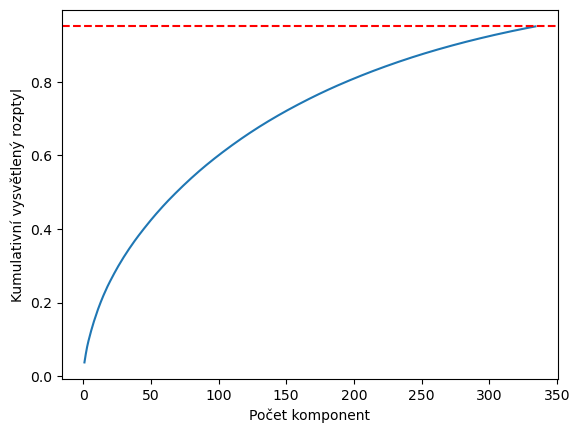

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [7]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [8]:
pred = svc.predict(X2)

In [9]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.832258064516129
Mcc: 0.3322277470925477


In [ ]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid(param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],        # Regularizační parametr
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],   # Typ kernelu
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Parametr pro 'rbf', 'poly', 'sigmoid'
    'degree': [2, 3, 4, 5],                            # Relevantní pouze pro 'poly' kernel
    'coef0': [0.0, 0.1, 0.5, 1.0],                    # Relevantní pro 'poly', 'sigmoid'
    'shrinking': [True, False]                         # Použití strategie "shrinking" pro optimalizaci
}
)

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    svc = SVC(random_state=69, **param)
    svc.fit(X1, y1["Y"])
    pred_svc = svc.predict(X2)
    val_mcc.append(matthews_corrcoef(pred_svc, y2["Y"]))
    val_f1.append(f1_score(pred_svc, y2["Y"]))
    val_acc.append(accuracy_score(pred_svc, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred_svc, y2["Y"]))



In [11]:
svc_res = pd.DataFrame(param_grid)

In [12]:
svc_res["mcc"] = val_mcc
svc_res["f1"] = val_f1
svc_res["acc"] = val_acc

In [13]:
svc_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [14]:
svc_res.to_csv("res/svc_without_smote_res_val_1.1.csv")

In [15]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [16]:
best_params

{'shrinking': True,
 'kernel': 'sigmoid',
 'gamma': 'scale',
 'degree': 2,
 'coef0': 0.0,
 'C': 10}

In [17]:
svc = SVC(**best_params)
svc.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1229: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=10, degree=2, kernel='sigmoid')

In [20]:
pred = svc.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8516129032258064
F1: 0.5106382978723404
Mcc: 0.45514956368175624


In [21]:
pred_test = svc.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.774390243902439
F1: 0.27450980392156865
Mcc: 0.16436315402932614
